In [61]:
from neural_priors.utils.data import Subject
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.odr import ODR, Model, RealData
import os
from pathlib import Path

sns.set_context('poster')

In [ ]:
bids_folder = Path('/data/ds-neuralpriors')
fig_folder = bids_folder / 'derivatives' / 'figures' / 'figure_dispersion_shift'
os.makedirs(fig_folder, exist_ok=True)

bids_folder = Path('/data/ds-neuralpriors')
pars = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models / 'group_roi-NPCr_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars.index.set_names('subject', level='subject_id', inplace=True)
cvr2_mask = pars[pars[('cvr2', 'nan')] > 0.0]


model_sd_slope_fixed_average_subjects = pars.xs(31, level='model_label', )

model_amplitude_free = pars.xs(32, level='model_label', )
model_amplitude_slope = pars.xs(33, level='model_label', )



In [63]:
pars = pd.concat((model_sd_slope_fixed_average_subjects, model_amplitude_free, model_amplitude_slope), axis=0,
                 keys=['sd_slope_fixed_average_subjects', 'amplitude_free', 'amplitude_slope'],
                 names=['model_label'])

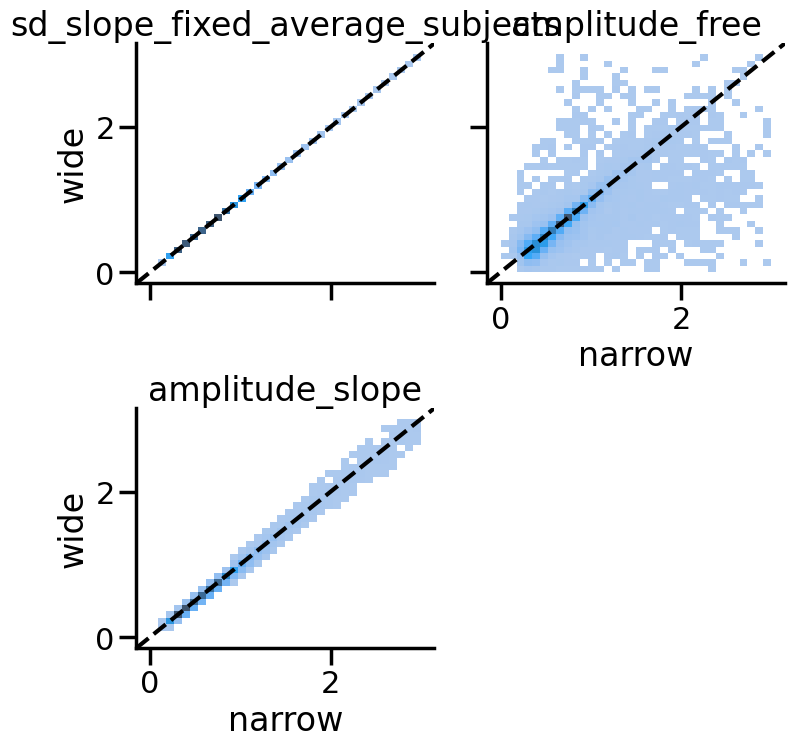

In [77]:
pars_ = pars[pars[('cvr2', 'nan')] > 0.0]

g = sns.FacetGrid(pars_['amplitude'].reset_index(), col='model_label', col_wrap=2, height=4, aspect=1.)

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 3, 35), np.linspace(0, 3, 35)],)

g.map(plt.axline, xy1=(0,0), slope=1, color='k', linestyle='--')
# plt.axline((0, 0), slope=1, color='k', linestyle='--')

g.set_titles('{col_name}')



In [65]:
pars_

parameter                                                    mu             \
range                                                    narrow       wide   
model_label                     subject smoothed                             
sd_slope_fixed_average_subjects 1       True     10   11.711694  13.423388   
                                                 13   11.601396  13.202791   
                                                 14   11.705684  13.411367   
                                                 16   11.351933  12.703865   
                                                 17   11.471527  12.943054   
...                                                         ...        ...   
amplitude_slope                 41      True     686  10.000180  10.000360   
                                                 688  13.257713  16.515427   
                                                 689  11.345229  12.690458   
                                                 691  11.812861  13.625723   
                                                 693  11.472737  12.945475   

parameter                                                   sd            \
range                                                   narrow      wide   
model_label                     subject smoothed                           
sd_slope_fixed_average_subjects 1       True     10   0.116724  0.150317   
                                                 13   0.119166  0.153461   
                                                 14   0.105055  0.135289   
                                                 16   0.130084  0.167521   
                                                 17   0.108114  0.139228   
...                                                        ...       ...   
amplitude_slope                 41      True     686  0.328602  0.423172   
                                                 688  0.613637  0.790238   
                                                 689  0.884992  1.139687   
                                                 691  0.787950  1.014717   
                                                 693  0.894983  1.152554   

parameter                                            delta_wide       \
range                                                    narrow wide   
model_label                     subject smoothed                       
sd_slope_fixed_average_subjects 1       True     10         2.0  2.0   
                                                 13         2.0  2.0   
                                                 14         2.0  2.0   
                                                 16         2.0  2.0   
                                                 17         2.0  2.0   
...                                                         ...  ...   
amplitude_slope                 41      True     686        2.0  2.0   
                                                 688        2.0  2.0   
                                                 689        2.0  2.0   
                                                 691        2.0  2.0   
                                                 693        2.0  2.0   

parameter                                            amplitude            \
range                                                   narrow      wide   
model_label                     subject smoothed                           
sd_slope_fixed_average_subjects 1       True     10   0.696296  0.696296   
                                                 13   0.657294  0.657294   
                                                 14   0.600074  0.600074   
                                                 16   0.462737  0.462737   
                                                 17   0.579319  0.579319   
...                                                        ...       ...   
amplitude_slope                 41      True     686  0.247239  0.272037   
                                                 688  0.393453  0.432916 

<Axes: ylabel='Count'>

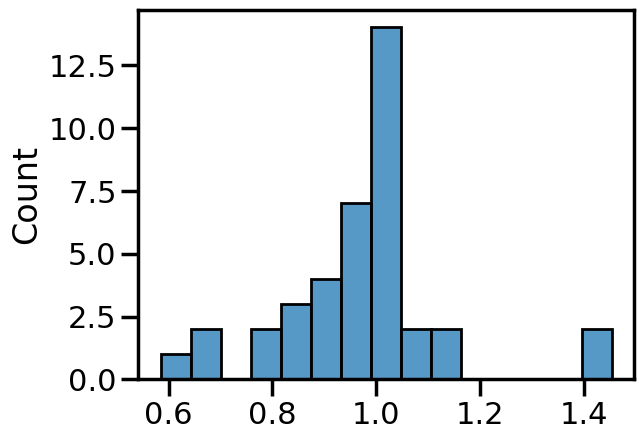

In [66]:
tmp = pars_.loc['amplitude_free']['amplitude']


sns.histplot((tmp['wide'] / tmp['narrow']).groupby(['subject']).median())

<Axes: ylabel='Count'>

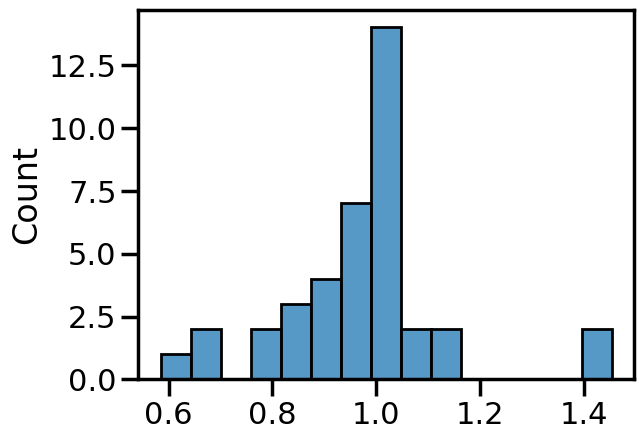

In [67]:
tmp = pars_.loc['amplitude_free']['amplitude']


sns.histplot((tmp['wide'] / tmp['narrow']).groupby(['subject']).median())

In [68]:
pars_.loc['amplitude_slope']['amplitude']
tmp['wide'] / tmp['narrow']

subject  smoothed     
1        True      7      0.539977
                   10     0.708892
                   13     0.792963
                   14     0.753846
                   16     0.853203
                            ...   
41       True      687    0.582053
                   688    1.007083
                   689    1.062532
                   691    1.052832
                   693    1.037067
Length: 8622, dtype: float64

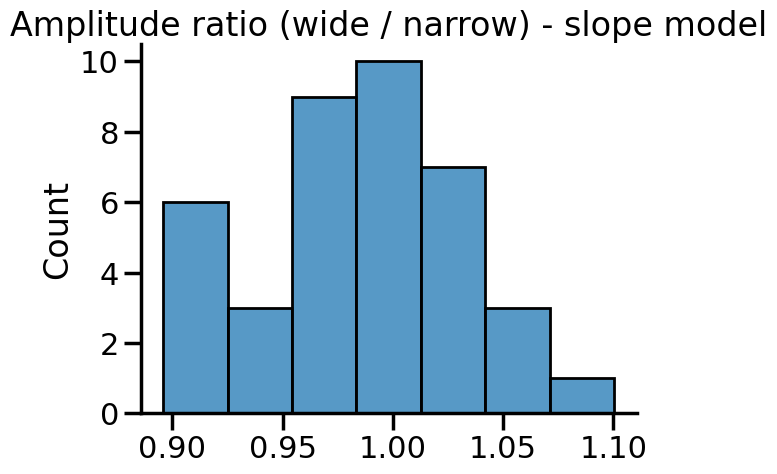

In [72]:
tmp = pars_.loc['amplitude_slope']['amplitude']


sns.histplot((tmp['wide'] / tmp['narrow']).groupby(['subject']).mean())

plt.title('Amplitude ratio (wide / narrow) - slope model')
sns.despine()

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,model_label,amplitude_free,amplitude_slope,True,True,-5.418128,38.0,two-sided,3.573918e-06,5229.678,-0.077959
1,model_label,amplitude_free,sd_slope_fixed_average_subjects,True,True,-6.411029,38.0,two-sided,1.556739e-07,9.723e+04,-0.098834
2,model_label,amplitude_slope,sd_slope_fixed_average_subjects,True,True,-2.714824,38.0,two-sided,9.918061e-03,4.143,-0.020884


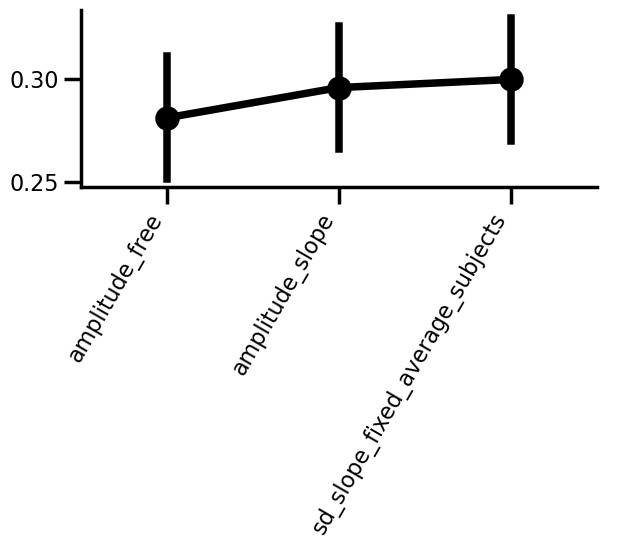

In [70]:
import pingouin as pg
prop_cvr2 = pars.groupby(['model_label', 'subject']).apply(lambda d: (d[('cvr2', 'nan')] > 0.0).mean()).to_frame('Proportion cvR2 > 0.0')


g = sns.catplot(
    data=prop_cvr2.reset_index(),
    x='model_label',
    y='Proportion cvR2 > 0.0',
    kind='point',
    height=4,
    aspect=1.5,
    color='k',
    errorbar='se',
)

g.set(xlabel=None, ylabel=None, title=None)

# Set fontsize yticks
for label in g.ax.get_yticklabels():
    label.set_fontsize(16)

# Rotate x-ticks
for label in g.ax.get_xticklabels():
    label.set_rotation(60)
    label.set_horizontalalignment('right')
    label.set_fontsize(16)

# Make figure square
g.fig.set_size_inches(8, 3)


pg.pairwise_tests(
    prop_cvr2.reset_index(),
    dv='Proportion cvR2 > 0.0',
    within='model_label',
    subject='subject',)